In [6]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [7]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra, StatsBase;

In [22]:
tbg_lattice = [[0, alevitov, 0], [-sqrt(3)/2*alevitov, -1/2*alevitov, 0], [0, 0, 1]]
tbg_reciprocal_lattice = reciprocal_vectors(tbg_lattice)

([-0.046889442590892436, 0.08121489690600975, 0.0], [-0.09377888518178487, 0.0, 0.0], [0.0, -0.0, 6.283185307179587])

In [57]:
N=100
epsilon_array=zeros(N, N)
for i in 1:N
    for j in 1:N
        epsilon_array[i, j] = -imag(1/(levitov_epsilon((tbg_reciprocal_lattice[1][1:2]*i/(2*N))..., 20*j/N, maxevals=10000)))
    end
end

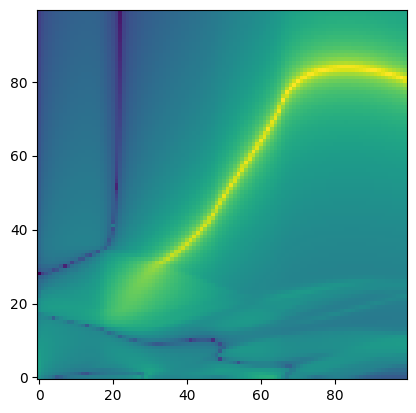

PyObject <matplotlib.image.AxesImage object at 0x7ffb07f8b790>

In [58]:
imshow(transpose(log.(abs.(epsilon_array))), origin="lower")

In [80]:
N=30
epsilon_array_kk=zeros(N, N)
for i in 1:N
    println(i)
    flush(stdout)
    for j in 1:N
        epsilon_array_kk[i, j] = JJDFTX.levitov_kramers_kronig_epsilon((tbg_reciprocal_lattice[1][1:2]*i/(2*N))..., 20*j/N)
    end
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30


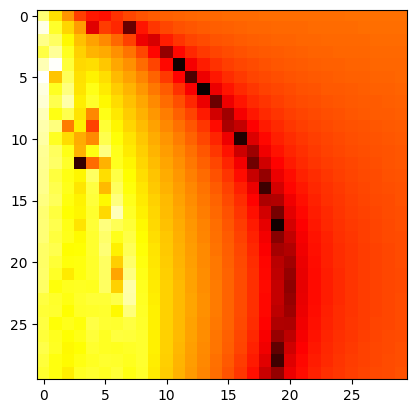

PyObject <matplotlib.image.AxesImage object at 0x7ffb077b9130>

In [85]:
imshow(log.(abs.(epsilon_array_kk)), cmap="hot")